## Interpreting Boolean sensitivity

Let us begin by studying a single node $v_i \in V$ with state $s_i^t$ at time $t$. This node had neighbourhood $\mathcal{N}(v_i)$. Like all other nodes, this node follows a local outer-totalistic update rule defined by the choice of the resolution, the survive set, and the born set, summarised as $R_r B_\beta S_\sigma$. In other words, the local update rule is
$$
s_i^{t+1} = \phi_{r,\sigma,\beta}(s_i^t, \rho_i^t), \qquad \text{with} \quad \rho_i^t = \frac{1}{|\mathcal{N}(v_i)|}\sum_{j\in \mathcal{N}(v_i)} s_j^t.
$$
Now, we want to evaluate **how often flipping the state of a single node in a particular configuration would flip the value of $s_i^{t+1}$**. For any given global configuration, we may identify a partition of all nodes:
1. $\{v_i\}$, i.e. the node itself,
2. $\mathcal{N}(v_i)$, i.e. the neighbourhood of node $v_i,
3. All other nodes that are not in $\mathcal{N}^*(v_i)$.

Here $\mathcal{N}^*(v_i) = \{v_i\} \cup \mathcal{N}(v_i)$.
We may introduce defects (i.e. flip the state of a single node) at time $t$ in either of these subsets.
1. Introducing a defect in $v_i$ will by definition affect the value of $s_i^t$.
2. Introducing a defect in a single node in $\mathcal{N}(v_i)$ will affect the value of $\rho_i^t$
3. Introducing a defect in a node in $V \setminus \mathcal{N}^*(v_i)$ will affect neither $s_i^t$ nor $\rho_i^t$.

### _a concrete simple example_

Now, as an example, consider a node $v_i$ with two neighbours $v_l, v_r \in \mathcal{N}(v_i)$. Together they form what we may call the totalistic neighbourhood $\mathcal{N}^*(v_i) = \mathcal{N}(v_i) \cup \{v_i\} = \{v_l, v_r, v_i\}$. This totalistic neighbourhood can take $2^{1+2} = 8$ configurations.

For notational purposes, let us pick an arbitrary order $(v_l, v_i, v_r)$. The set of possible configurations can then be written out as
$$
P = \{(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)\} = \{0, 1\}^3.
$$
Each of these configurations can be perturbed in three different ways, by introducing a defect in any of the nodes. Let us first consider a partition of the set of configurations based on the sum of the states of $v_l$ and $v_r$:
$$
P = \{(0, 0, 0), (0, 1, 0)\} \cup \{(0, 0, 1), (1, 0, 0), (0, 1, 1), (1, 1, 0)\} \cup \{(1, 0, 1), (1, 1, 1)\} = P_0 \cup P_1 \cup P_2,
$$
where the index is equal to the **sum of living neighbours**. Note that $|P_0| = |P_2| = 2$, while $|P_1| = 4$. Each of these subsets can be partitioned further into two subsubsets of equal cardinality, depending on the value of $v_i$, so
$$
\begin{align*}
P_0 &= P_{0,0} \cup P_{0,1} = \{(0, 0, 0)\} \cup \{(0, 1, 0)\},\\
P_1 &= P_{1,0} \cup P_{1,1} = \{(0, 0, 1), (1, 0, 0)\} \cup \{(0, 1, 1), (1, 1, 0)\},\\
P_2 &= P_{2,0} \cup P_{2,1} = \{(1, 0, 1)\} \cup \{(1, 1, 1)\}.
\end{align*}
$$
In other words, the total set of configuration can be written as a double indexed union
$$
P = \bigcup_{s_i \in \{0,1\}} \bigcup_{q=0}^2 P_{{s_i},q}
$$
Due to the outer-totalistic nature of our family of network automata, configurations in the same subsubset $P_{{s_i},q}$ will always result in the same value of the node $v_i$ in the next time step. Configurations in a different subsubset may or may not result in the same value. The more they do, the higher our total Boolean sensitivity is said to be.

Now, elaborating a bit more on our concrete simple example, say that we introduce a defect in a random node of a configuration in $P_{1,0}$.
1. There is a probability of $1/3$ that this node is the central node $v_i$, which would map the configuration from $P_{1,0} \rightarrow P_{1,1}$.
2. There is a probability of $2/3$ that this node is in $\mathcal{N}(v_i)$. Because of the distribution of states, there are two possibilites:
    - There is a probability of $1/2$ that the sum of states increases, which maps the configuration from $P_{1,0} \rightarrow P_{2,0}$,
    - There is a probability of $1/2$ that the sum of state decreases, such that $P_{1,0} \rightarrow P_{0,0}$.

The first probability depends on the number of nodes in the neighbourhood of $v_i$. The second probability depends on how many living neighbours there are: changing a living neighour's state will decrease the density, while changing a dead neighbour's state will increase the density.

## Defining Boolean sensitivity for an outer-totalistic local update rule
(_for a single node, and for a uniform random initial configuration_)

Let us consider the case where every configuration is equally likely (uniform distribution). Let us call $d_i = |\mathcal{N}(v_i)|$ the degree of node $v_i$. Following the principles outlined above, we then find that the total Boolean sensitivity related to node $v_i$ is
$$
S_i = \frac{1}{2^{d_i+1}}\sum_{s \in \{0,1\}} \sum_{q=0}^{d_i}\binom{d_i}{q} \left\{ \frac{1}{d_i+1}\text{IS}(s_i, q, d_i) + \frac{d_i}{d_i+1}\left[\left(\frac{q}{d_i}\text{NS}_\text{dec}(s_i, q, d_i) + \frac{d_i-q}{d_i}\text{NS}_\text{inc}(s_i, q, d_i)\right)\right]\right\}.
$$
Here we call upon two terms. The first expresses how _sensitive_ the node's state in the next time step is to changing its _identity_ (i.e. its own original state). We call this the **identity sensitivity**,
$$
\text{IS}(s_i, q, d_i) = \phi\left(s,\frac{q}{d_i}\right) \oplus \phi\left(s \oplus 1, \frac{q}{d_i}\right),
$$
where $\oplus$ is the XOR operator. The IS takes the value $1$ if the output of the function changes upon flipping state $s_i$, and $0$ otherwise.

The second term expresses how _sensitive_ the node's state in the next time step is to changing the density of its _neighbourhood_. Depending on the configuration of the neighbourhood, the density can be _increased_ or _decreased_,
$$
\begin{align*}
\text{NS}_\text{dec}(s_i, q, d_i) &= \phi\left(s_i,\frac{q-1}{d_i}\right) \oplus \phi\left(s_i,\frac{q}{d_i}\right)\\
\text{NS}_\text{inc}(s_i, q, d_i) &= \phi\left(s_i,\frac{q+1}{d_i}\right)\oplus \phi\left(s_i,\frac{q}{d_i}\right)
\end{align*}
$$

Note that $\phi(s,\rho)$ is undefined for $\rho \not\in [0,1]$, but terms involving that expression do not contribute to the sum. We call the weighted sum of both possibilities the **neighbourhood sensitivity**. Additionally, note that the factor $d_i$ typically means that the neighbourhood sensitivity will contribute (much) more to the total Boolean sensitivity than the identity sensitivity.

For the sake of being complete, let us again run over all contributing elements
1. We divide over $2^{d_i+1}$, the total number of configurations in $P$ (all possible configurations of nodes in $\mathcal{N}^*(v_i)$).
2. We sum over the values of $q$, and multiply by the binomium $\binom{d_i}{q}$. After all, this is the number of configurations that correspond to $q$ living neighbours in $\mathcal{N}(v_i)$.
3. The prefactors $\frac{1}{d_i+1}$ and $\frac{d_i}{d_i+1}$ indicate the fraction of perturbations that affect resp. the node $v_i$ or the nodes in $\mathcal{N}(v_i)$.
4. The prefactors $\frac{q}{d_i}$ and $\frac{d_i-q}{d_i}$ indicate the fraction of perturbations that affect resp. living nodes or dead nodes in $\mathcal{N}(v_i)$.

Concluding, we can write this more elegantly. Isolating some common factors, we find
$$
\boxed{
S_i = \frac{2^{-(d_i+1)}}{(d_i+1)}\sum_{s \in \{0,1\}} \sum_{q=0}^{d_i}\binom{d_i}{q} \Big\{ \text{IS}(s_i, q, d_i) + \text{NS}(s_i, q, d_i)\Big\}.
}
$$
with
$$
\text{NS}(s_i, q, d_i) = q\text{NS}_\text{dec}(s_i, q, d_i) + (d_i-q)\text{NS}_\text{inc}(s_i, q, d_i)
$$

The highest possible value of the IS is $1$, and that of the NS is $d_i$. Note that the value of $S_i$ therefore runs from $0$ to $1$, as desired. We should note that this distinction between NS and IS is not commonplace, but we introduced it because of the clear visual interpretation that it offers.

## Visual interpretation of IS and NS

In order to make the interpretation of IS and NS more clear, consider the LLNA $R_3 B_6 S_3$. Additionally, consider that we still inspect the behaviour of node $v_i$ that only has two neighbours. The density of living neighbours can therefore only be $0$, $1/2$ or $1$. This is indicated in the LLNA diagram below.

In [1]:
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

%load_ext autoreload
%autoreload 2

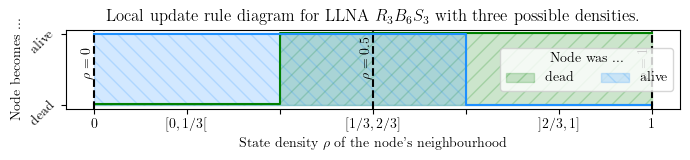

In [17]:
SAVEFIG=False

fig, ax = plt.subplots(1,1,figsize=(7,1.7))

# define model
resolution = 3
born_if = [1, 2]
survive_if = [0,1]
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# draw diagram
model.diagram(ax=ax)

for rho in [0, 1/2, 1]:
    ax.axvline(rho, color='k', ls='--')
    ax.text(rho-.025, 1-.618, fr"$\rho={np.round(rho,1)}$", rotation=90)
# set title
ax.set_title(f"Local update rule diagram for LLNA {model.__str__(latex=True)} with three possible densities.")

fig.tight_layout()
if SAVEFIG:
    # Note: saving as PDF fails to show the hatches
    plt.savefig(f"update-rule-diagram_rule{model.__str__()}.png", dpi=600)

When performing the double summation in the boxed equation seen earlier, the visual interpretation is as follows:
1. When $s_i = 0$, we only look at the green diagram (with diagonals going to the upper right). When $s_i = 1$, we only look at the blue diagram (with diagonals going to the upper left)
2. For a value $q$, we look at the location in the diagram indicated by the vertical dashed line corresponding to $\rho = q/d_i$.

Then, having chosen a location to consider, calculate the number of neighbourhood configuration that can result in this location: $\binom{d_i}{q}$. Then count the following

1. When changing colour at this location, does the output change? If so, add $1$.
2. When moving to the left (if possible), does the output change? If so, add $q$.
3. When moving to the right (if possible), does the output change? If so, add $d_i-q$.

This results in a number that you should multiply by the factor $\binom{d_i}{q}$. Then move on to the next step in the dobule summation.

Some remarks may be of interest:
- Every combination of local update rule and degree $d_i$ is associated with a single value for the Boolean sensitivity $S_i$.
- The number of possible $S_i$ values is limited by the discrete nature of the problem, and also by two additional identities:
    - $\text{IS}(s_i, q, d_i) = \text{IS}(s_i \oplus 1, q, d_i),$
    - $\text{NS}_\text{dec}(s_i, q, d_i) = \text{NS}_\text{inc}(s_i, q+1, d_i)$
- the number of possible $S_i$ values for high ratios of $d_i/r$ is also limited, because in that case most perturbations in the neighbourhood will not alter the density so much that it changes from density interval. (we could implement this in the formula, but it's not that much computational work to just also calculate the superfluous cases).

## Calculating the Boolean sensitivity

In [20]:
# TODO: enter code for S_i

## Boolean sensitivity over all nodes

- As a first approximation, take sum over all nodes for $S_i$ for all its possible neighbourhood configurations
- As a second approximation, take a sum over all possible global configurations (or a sample thereof), summing the local $S_i$ for all nodes (in that case the neighbourhood configurations will be inter-dependent, which is more realistic)
- As a third step, generalise to non-uniform distributions
    - e.g. a probability of 70 percent living nodes
    - e.g. the probability of being alive is linked to the node degree
    - e.g. a Markov configuration, where linked nodes are more likely to be in the same state (check with ChatGPT how that would work in the context of a network, because contradictions may arise)

For a more general probability distribution:
$$
S_i = \sum_{s_i \in \{0,1\}} \sum_{q=0}^{d_i} P(s_i, q | d_i) \left\{ \frac{1}{d_i+1} \text{IS}(s_i, q, d_i) + \frac{d_i}{d_i+1} \left[ \frac{q}{d_i} \text{NS}_\text{dec}(s_i, q, d_i) + \frac{d_i-q}{d_i} \text{NS}_\text{inc}(s_i, q, d_i) \right] \right\}
$$
For example in a binomial distribution with probability of a living node $p$, the probability mass function is
$$
P(s_i, q | d_i) = \text{Binom}(s_i + q, d_i+1, p) = \binom{d_i+1}{s_i+q}p^{s_i+q}(1-p)^{d_i+1-s_i-q}
$$


## Boolean sensitivity over time
- The probability distribution of configurations changes over time because of the network automaton process
- This affects Boolean sensitivity
- Eventually we end up with the Lyapunov spectrum, I think?
- Make use of Derrida plots (from work from 80s)

In [18]:
# TODO: make sure that the Boolean sensitivity is the same for isomorphic LLNAs!